<a href="https://colab.research.google.com/github/trinhkimngan1602/BaitapAI01/blob/main/Vietnamesefooddishes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt

# ĐƯỜNG DẪN: Nếu bạn để thư mục Vietnamese_Dishes ngay ngoài cùng của Drive thì đường dẫn sẽ như sau:
base_dir = '/content/drive/MyDrive/Vietnamese_Dishes'

# Kiểm tra xem đường dẫn có đúng không
if os.path.exists(base_dir):
    print("✅ Đã tìm thấy thư mục ảnh!")
    print("Danh sách các món ăn:", os.listdir(base_dir))
else:
    print("❌ Không tìm thấy thư mục. Bạn hãy kiểm tra lại tên thư mục trên Drive.")

# CẤU HÌNH THÔNG SỐ
img_shape = (150, 150)
batch_size = 32

# TĂNG CƯỜNG DỮ LIỆU
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Chia 20% ảnh để kiểm tra độ chính xác
)

# Load ảnh vào code
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_shape,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_shape,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

✅ Đã tìm thấy thư mục ảnh!
Danh sách các món ăn: ['Bun dau mam tom', 'Com tam', 'Banh mi', 'Banh beo', 'Goi cuon']
Found 1200 images belonging to 5 classes.
Found 300 images belonging to 5 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# --- BƯỚC 1: XÂY DỰNG CẤU TRÚC MẠNG CNN ---
model = Sequential([
    # Lớp Conv 1: Tìm các đường nét, màu sắc cơ bản
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Lớp Conv 2: Tìm các hình khối phức tạp hơn
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Lớp Conv 3: Đi sâu vào chi tiết món ăn
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Chuyển dữ liệu từ dạng mảng sang dạng phẳng để phân loại
    Flatten(),

    # Lớp ẩn: Với 512 nút thần kinh để ghi nhớ đặc điểm
    Dense(512, activation='relu'),

    # Dropout giúp chống "học vẹt" (Overfitting)
    Dropout(0.5),

    # Lớp đầu ra: Có 5 nút tương ứng với 5 món ăn của bạn
    Dense(5, activation='softmax')
])

# --- BƯỚC 2: BIÊN DỊCH MÔ HÌNH ---
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Xem tóm tắt cấu trúc mạng
model.summary()

# --- BƯỚC 3: BẮT ĐẦU CHO MÁY HỌC (TRAINING) ---
print("\n🔥 Đang bắt đầu huấn luyện... Vui lòng đợi...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=50, # Bạn có thể tăng lên 20->30 nếu muốn máy học kỹ hơn
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 32
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,229 (72.62 MB)

 Trainable params: 19,036,229 (72.62 MB)

 Non-trainable params: 0 (0.00 B)


🔥 Đang bắt đầu huấn luyện... Vui lòng đợi...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 880ms/step - accuracy: 0.2380 - loss: 1.7166 - val_accuracy: 0.2465 - val_loss: 1.5782
Epoch 2/50
 1/37 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2188 - loss: 1.5908

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.2188 - loss: 1.5908 - val_accuracy: 0.3021 - val_loss: 1.5701
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 742ms/step - accuracy: 0.2962 - loss: 1.5602 - val_accuracy: 0.3576 - val_loss: 1.4923
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.5312 - loss: 1.3816 - val_accuracy: 0.3194 - val_loss: 1.5575
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 762ms/step - accuracy: 0.3382 - loss: 1.5135 - val_accuracy: 0.3646 - val_loss: 1.4316
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.3125 - loss: 1.3999 - val_accuracy: 0.4479 - val_loss: 1.4319
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 27s 731ms/step - accuracy: 0.3887 - loss: 1.4115 - val_accuracy: 0.4861 - val_loss: 1.3336
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.4688 - loss: 1.2993 - val_accuracy: 0.4514 - val_loss: 1.3838
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 27s 743ms/step - accuracy: 0.4401 - loss: 1.3460 - val_accuracy: 0.4688 - 

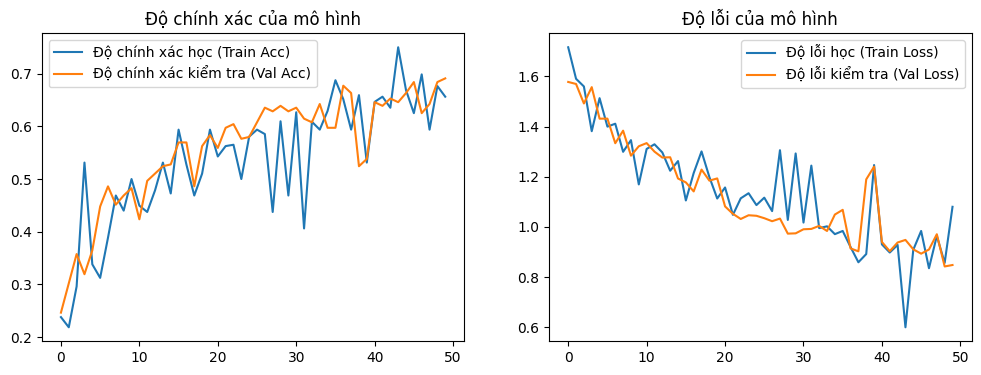

✅ Đã lưu mô hình thành công!
Mời bạn tải ảnh món ăn lên để máy nhận diện...


Saving banhbeotest.png to banhbeotest.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


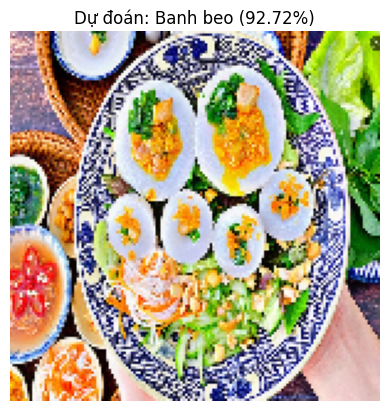

Kết quả: Đây là món Banh beo với độ tin cậy 92.72%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

# --- BƯỚC 1: VẼ ĐỒ THỊ KẾT QUẢ ---
# Giúp bạn xem máy học có tốt không (đường Accuracy đi lên là tốt)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Độ chính xác học (Train Acc)')
plt.plot(epochs_range, val_acc, label='Độ chính xác kiểm tra (Val Acc)')
plt.title('Độ chính xác của mô hình')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Độ lỗi học (Train Loss)')
plt.plot(epochs_range, val_loss, label='Độ lỗi kiểm tra (Val Loss)')
plt.title('Độ lỗi của mô hình')
plt.legend()
plt.show()

# --- BƯỚC 2: LƯU MÔ HÌNH THÀNH FILE ---
# Lưu lại để sau này dùng luôn, không cần huấn luyện lại (mất thời gian)
model.save('model_nhan_dien_mon_an.h5')
print("✅ Đã lưu mô hình thành công!")

# --- BƯỚC 3: HÀM DỰ ĐOÁN ẢNH BẤT KỲ ---
def nhan_dien_mon_an():
    # Lấy danh sách tên món ăn từ generator
    class_names = list(train_generator.class_indices.keys())

    print("Mời bạn tải ảnh món ăn lên để máy nhận diện...")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # Xử lý ảnh tải lên
        path = fn
        img = image.load_img(path, target_size=(150, 150))
        img_tensor = image.img_to_array(img)
        img_tensor = np.expand_dims(img_tensor, axis=0)
        img_tensor /= 255.

        # Dự đoán
        prediction = model.predict(img_tensor)
        score = tf.nn.softmax(prediction[0])

        # Hiển thị kết quả
        class_idx = np.argmax(prediction[0])
        confidence = prediction[0][class_idx] * 100

        plt.imshow(img)
        plt.title(f"Dự đoán: {class_names[class_idx]} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"Kết quả: Đây là món {class_names[class_idx]} với độ tin cậy {confidence:.2f}%")

# Gọi hàm để kiểm tra thử
nhan_dien_mon_an()